**Task**

Create a **Graph** where you pass in a single list of integers along with a name and an operation. If the operation is a "+", you **add** the elements and if it is a "*", you **multiply** the elements, **all within the same node.**


**input:** {"name":"Jack", "values":[1,2,3,4], "operation":"+"}

**Output**: "Hi, Jack, your answer is: 25"

*Hint*: You need an if-statement in your node

In [10]:
from typing import TypedDict, List
from langgraph.graph import StateGraph
import math

In [6]:
#create the state schema

class AgentState(TypedDict):
    values:List[int]
    name:str
    operation:str
    results:str
    

In [11]:
#Create the node

def calculation(state: AgentState)->AgentState:
    """Performs addition or multiplication of numbers"""
    if state['operation']=='+':
        state['results']=f"Hi, {state['name']}, your answer is {sum(state['values'])}"

        #now return state
        return state
    
    elif state['operation']=='*':
        state['results']=f"Hi, {state['name']}, your answer is {math.prod(state['values'])}"

        return state

In [12]:
# now create the graph

graph=StateGraph(AgentState)

#add the node
graph.add_node('calculate', calculation)

#add Start
graph.set_entry_point('calculate')

#End of the graph
graph.set_finish_point('calculate')

#compile the graph

app=graph.compile()

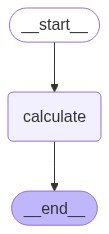

In [13]:
#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


In [ ]:
#test the workflow-- Update the state of the graph
result=app.invoke({'name':'Jack', 'values':[1,2,3,6,90], 'operation':'*'})

In [ ]:
#lets see what is stored in our state graph result key
result['results']

'Hi, Jack, your answer is 3240'